Using device: cpu


100%|██████████| 170M/170M [00:03<00:00, 47.3MB/s]


Dataset loaded successfully.


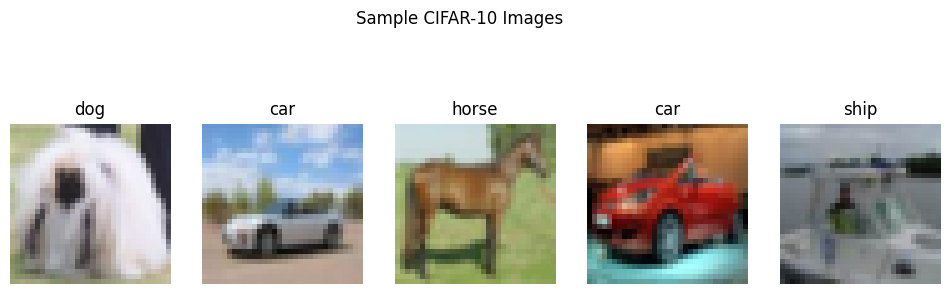

Training Shallow CNN...

Epoch [1/10] Loss: 1.3188 Accuracy: 52.76%
Epoch [2/10] Loss: 0.9502 Accuracy: 66.67%
Epoch [3/10] Loss: 0.8002 Accuracy: 71.77%
Epoch [4/10] Loss: 0.6821 Accuracy: 76.09%
Epoch [5/10] Loss: 0.5751 Accuracy: 79.99%
Epoch [6/10] Loss: 0.4827 Accuracy: 83.20%
Epoch [7/10] Loss: 0.3933 Accuracy: 86.17%
Epoch [8/10] Loss: 0.3145 Accuracy: 88.98%
Epoch [9/10] Loss: 0.2442 Accuracy: 91.46%
Epoch [10/10] Loss: 0.1864 Accuracy: 93.58%

Test Accuracy: 72.67%
Training Medium CNN...

Epoch [1/10] Loss: 1.3726 Accuracy: 49.88%
Epoch [2/10] Loss: 0.9200 Accuracy: 67.21%
Epoch [3/10] Loss: 0.7092 Accuracy: 74.92%
Epoch [4/10] Loss: 0.5599 Accuracy: 80.25%
Epoch [5/10] Loss: 0.4362 Accuracy: 84.57%
Epoch [6/10] Loss: 0.3205 Accuracy: 88.59%
Epoch [7/10] Loss: 0.2210 Accuracy: 92.22%
Epoch [8/10] Loss: 0.1569 Accuracy: 94.52%
Epoch [9/10] Loss: 0.1227 Accuracy: 95.57%
Epoch [10/10] Loss: 0.0985 Accuracy: 96.49%

Test Accuracy: 75.14%
Training Deep CNN...

Epoch [1/10] Loss: 1.

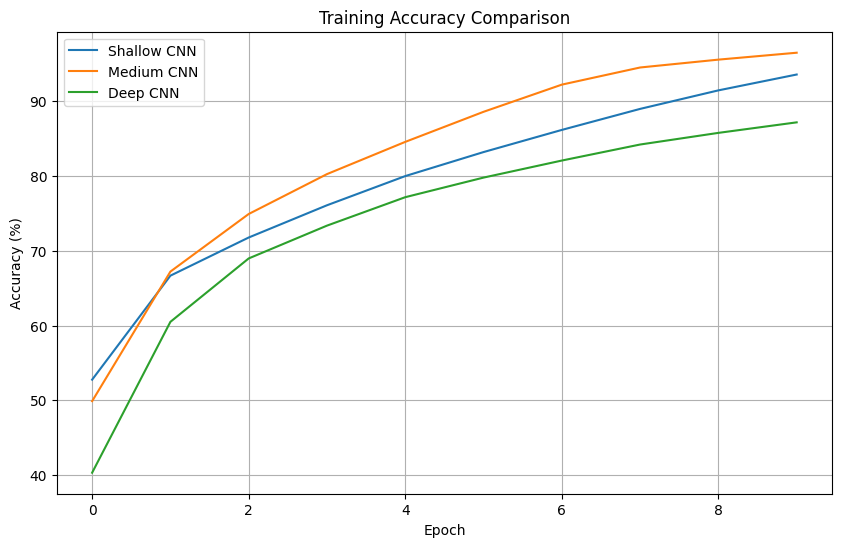

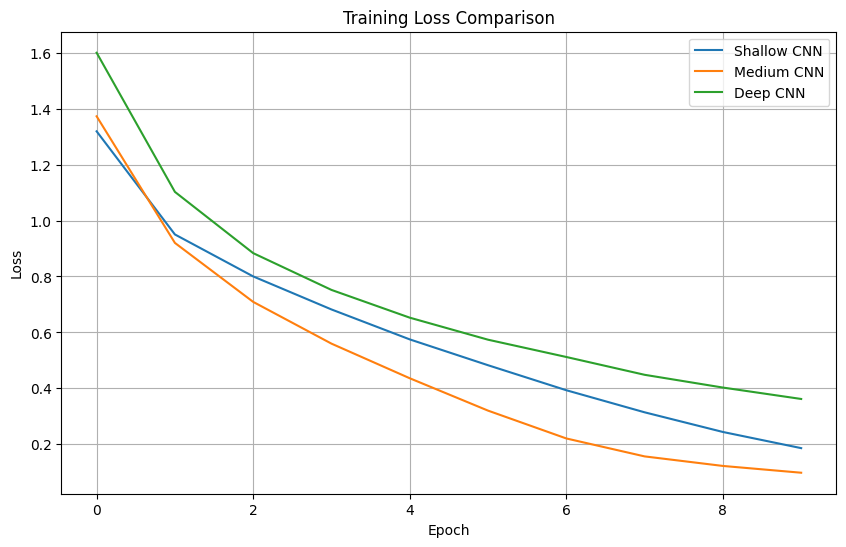

         Model  Test Accuracy
0  Shallow CNN          72.67
1   Medium CNN          75.14
2     Deep CNN          77.57


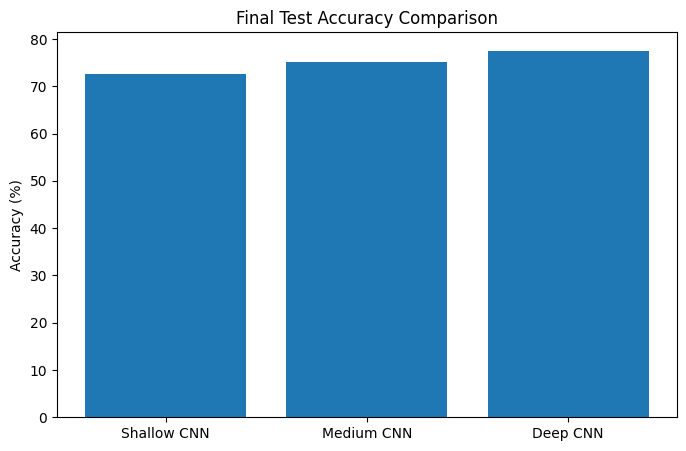

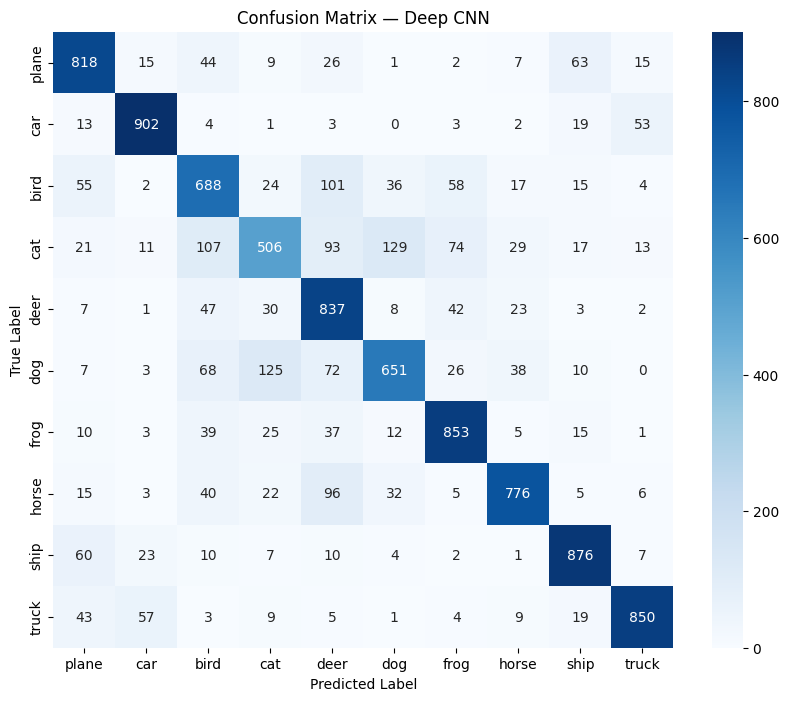

              precision    recall  f1-score   support

       plane       0.78      0.82      0.80      1000
         car       0.88      0.90      0.89      1000
        bird       0.66      0.69      0.67      1000
         cat       0.67      0.51      0.58      1000
        deer       0.65      0.84      0.73      1000
         dog       0.74      0.65      0.69      1000
        frog       0.80      0.85      0.82      1000
       horse       0.86      0.78      0.81      1000
        ship       0.84      0.88      0.86      1000
       truck       0.89      0.85      0.87      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.77     10000
weighted avg       0.78      0.78      0.77     10000



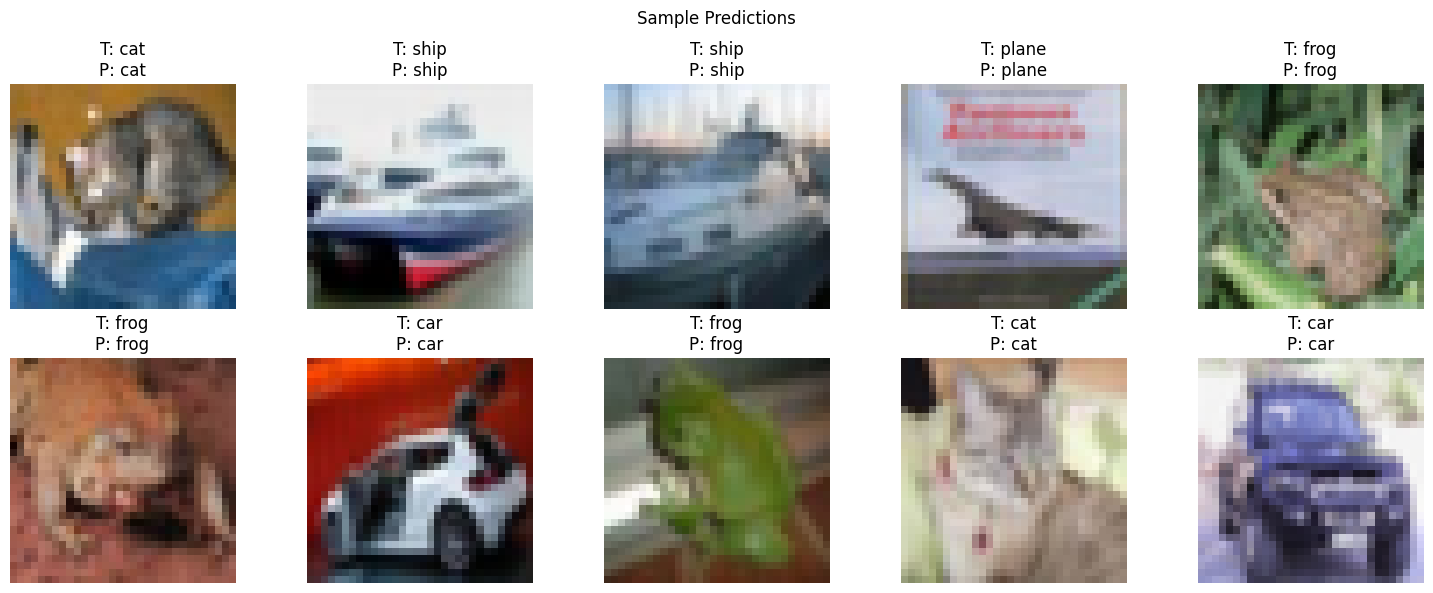

Models saved successfully.


In [ ]:
# ============================================
# INSTALL REQUIRED PACKAGES
# ============================================

# !pip install torch torchvision matplotlib seaborn scikit-learn pandas

# ============================================
# IMPORT LIBRARIES
# ============================================

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report

# ============================================
# DEVICE CONFIGURATION
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ============================================
# DATA PREPROCESSING
# ============================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# ============================================
# LOAD CIFAR-10 DATASET
# ============================================

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = (
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

print("Dataset loaded successfully.")

# ============================================
# DISPLAY SAMPLE IMAGES
# ============================================

images, labels = next(iter(trainloader))

fig, axes = plt.subplots(1, 5, figsize=(12,4))

for i in range(5):

    img = images[i] / 2 + 0.5
    npimg = img.numpy()

    axes[i].imshow(np.transpose(npimg, (1,2,0)))

    axes[i].set_title(classes[labels[i]])

    axes[i].axis('off')

plt.suptitle("Sample CIFAR-10 Images")

plt.show()

# ============================================
# SHALLOW CNN MODEL
# ============================================

class ShallowCNN(nn.Module):

    def __init__(self):

        super(ShallowCNN, self).__init__()

        self.network = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        return self.network(x)

# ============================================
# MEDIUM CNN MODEL
# ============================================

class MediumCNN(nn.Module):

    def __init__(self):

        super(MediumCNN, self).__init__()

        self.network = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        return self.network(x)

# ============================================
# DEEP CNN MODEL
# ============================================

class DeepCNN(nn.Module):

    def __init__(self):

        super(DeepCNN, self).__init__()

        self.network = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 10)
        )

    def forward(self, x):

        return self.network(x)

# ============================================
# TRAINING FUNCTION
# ============================================

def train_model(model, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):

        running_loss = 0.0

        correct = 0
        total = 0

        model.train()

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        epoch_loss = running_loss / len(trainloader)

        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)

        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    return train_losses, train_accuracies

# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_preds.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = 100 * correct / total

    print(f"\nTest Accuracy: {accuracy:.2f}%")

    return accuracy, all_preds, all_labels

# ============================================
# TRAIN SHALLOW CNN
# ============================================

print("Training Shallow CNN...\n")

shallow_model = ShallowCNN()

shallow_losses, shallow_accuracies = train_model(
    shallow_model,
    epochs=10
)

shallow_test_acc, shallow_preds, shallow_labels = evaluate_model(
    shallow_model
)

# ============================================
# TRAIN MEDIUM CNN
# ============================================

print("Training Medium CNN...\n")

medium_model = MediumCNN()

medium_losses, medium_accuracies = train_model(
    medium_model,
    epochs=10
)

medium_test_acc, medium_preds, medium_labels = evaluate_model(
    medium_model
)

# ============================================
# TRAIN DEEP CNN
# ============================================

print("Training Deep CNN...\n")

deep_model = DeepCNN()

deep_losses, deep_accuracies = train_model(
    deep_model,
    epochs=10
)

deep_test_acc, deep_preds, deep_labels = evaluate_model(
    deep_model
)

# ============================================
# ACCURACY COMPARISON PLOT
# ============================================

plt.figure(figsize=(10,6))

plt.plot(shallow_accuracies, label='Shallow CNN')

plt.plot(medium_accuracies, label='Medium CNN')

plt.plot(deep_accuracies, label='Deep CNN')

plt.title("Training Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# LOSS COMPARISON PLOT
# ============================================

plt.figure(figsize=(10,6))

plt.plot(shallow_losses, label='Shallow CNN')

plt.plot(medium_losses, label='Medium CNN')

plt.plot(deep_losses, label='Deep CNN')

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# FINAL RESULTS TABLE
# ============================================

results = pd.DataFrame({

    "Model": [
        "Shallow CNN",
        "Medium CNN",
        "Deep CNN"
    ],

    "Test Accuracy": [
        shallow_test_acc,
        medium_test_acc,
        deep_test_acc
    ]
})

print(results)

# ============================================
# FINAL ACCURACY BAR CHART
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Test Accuracy"]
)

plt.title("Final Test Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.show()

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    deep_labels,
    deep_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix — Deep CNN")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

# ============================================
# CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        deep_labels,
        deep_preds,
        target_names=classes
    )
)

# ============================================
# SAMPLE PREDICTIONS
# ============================================

images, labels = next(iter(testloader))

images_device = images.to(device)

outputs = deep_model(images_device)

_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, ax in enumerate(axes.flat):

    img = images[i] / 2 + 0.5

    npimg = img.numpy()

    ax.imshow(np.transpose(npimg, (1,2,0)))

    true_label = classes[labels[i]]

    pred_label = classes[predicted[i]]

    ax.set_title(
        f"T: {true_label}\nP: {pred_label}"
    )

    ax.axis('off')

plt.suptitle("Sample Predictions")

plt.tight_layout()

plt.show()

# ============================================
# SAVE MODELS
# ============================================

torch.save(
    shallow_model.state_dict(),
    "shallow_cnn.pth"
)

torch.save(
    medium_model.state_dict(),
    "medium_cnn.pth"
)

torch.save(
    deep_model.state_dict(),
    "deep_cnn.pth"
)

print("Models saved successfully.")